# From Pilot to Payoff - 03: Q2 - Country-Level Digital Readiness

Q2: Are country-level digital readiness factors associated with advanced AI adoption?


### Q2 - Country-Level Digital Readiness

Here we link each country's digital-readiness indicators (from `country_ai_index.csv`) to its advanced-adoption rate. With only 30 countries this is exploratory, so we keep it simple: correlate each indicator with adoption, check the VIFs, combine the indicators into one PCA index because they are so correlated, and then regress adoption on that single index.

## Setup and data preparation

Loads the data, builds the advanced-adoption flag, and merges in the country readiness indicators.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from scipy import stats

import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
company = pd.read_csv('ai_company_adoption.csv')
country_index = pd.read_csv('country_ai_index.csv')
print(f'company: {company.shape[0]:,} x {company.shape[1]}    country index: {country_index.shape[0]} x {country_index.shape[1]}')
company.head(3)


company: 150,000 x 43    country index: 30 x 8


,response_id,company_id,survey_year,quarter,country,region,industry,company_size,num_employees,annual_revenue_usd_millions,...,productivity_change_percent,jobs_displaced,jobs_created,reskilled_employees,revenue_growth_percent,cost_reduction_percent,innovation_score,customer_satisfaction,survey_source,data_collection_method
0,1,COMP-00001,2023,Q1,Italy,Europe,Education,Startup,57,48.31,...,2.65,1,1,3,2.52,9.45,53,5.20,WEF Survey,API Scrape
1,2,COMP-00001,2023,Q2,Italy,Europe,Education,Startup,57,48.31,...,5.77,2,2,5,4.77,0.00,51,6.98,McKinsey Report,Phone Interview
2,3,COMP-00001,2023,Q3,Italy,Europe,Education,Startup,57,48.31,...,6.94,3,3,2,12.87,9.74,40,4.12,Internal Corporate Survey,Research Compilation


In [3]:
# Feature engineering: advanced-adoption target + country readiness indicators.
company = company.copy()
company['advanced_adoption'] = company['ai_adoption_stage'].isin(['partial', 'full']).astype(int)

country_model = country_index.drop(columns=['region'])
country_model['log_gdp_per_capita'] = np.log1p(country_model['gdp_per_capita'])
country_model['log_ai_patent_filings_2024'] = np.log1p(country_model['ai_patent_filings_2024'])

df = company.merge(country_model, on='country', how='left')
print(f'Merged data: {df.shape[0]:,} rows x {df.shape[1]:,} columns')


Merged data: 150,000 rows x 52 columns


In [4]:
country_level = (df.groupby('country')
                   .agg(
                       adv_adoption_rate=('advanced_adoption', 'mean'),
                       log_gdp_per_capita=('log_gdp_per_capita', 'first'),
                       internet_penetration=('internet_penetration', 'first'),
                       digital_maturity_index=('digital_maturity_index', 'first'),
                       log_ai_patent_filings_2024=('log_ai_patent_filings_2024', 'first'),
                       ai_researchers_per_million=('ai_researchers_per_million', 'first'))
                   .reset_index())

readiness_features = [
    'log_gdp_per_capita',
    'internet_penetration',
    'digital_maturity_index',
    'log_ai_patent_filings_2024',
    'ai_researchers_per_million'
]

# Correlate each readiness indicator with the country's advanced-adoption rate (significant if p < 0.05).
corr_rows = []
for col in readiness_features:
    r, p = stats.pearsonr(country_level[col], country_level['adv_adoption_rate'])
    corr_rows.append({'readiness_indicator': col, 'pearson_r': r, 'p_value': p})

country_corr_table = pd.DataFrame(corr_rows).sort_values('pearson_r', ascending=False)
country_corr_table


,readiness_indicator,pearson_r,p_value
0,log_gdp_per_capita,0.643397,0.000125
4,ai_researchers_per_million,0.538635,0.002135
2,digital_maturity_index,0.537943,0.002169
1,internet_penetration,0.537669,0.002182
3,log_ai_patent_filings_2024,0.426704,0.018696


In [5]:
# VIF for country readiness variables.
def compute_vif(data, columns):
    X = data[columns].dropna().copy()
    X_std = pd.DataFrame(StandardScaler().fit_transform(X), columns=columns, index=X.index)
    X_const = sm.add_constant(X_std)
    return (pd.DataFrame({
        'variable': columns,
        'VIF': [variance_inflation_factor(X_const.values, i + 1) for i in range(len(columns))]
    }).sort_values('VIF', ascending=False))

country_vif = compute_vif(country_level, readiness_features)
country_vif


,variable,VIF
4,ai_researchers_per_million,17.911738
0,log_gdp_per_capita,16.985121
2,digital_maturity_index,14.819939
1,internet_penetration,9.564445
3,log_ai_patent_filings_2024,3.303517


PCA explained variance ratio
PC1    0.868
PC2    0.084
dtype: float64

PCA loadings
                   feature  PC1_loading  PC2_loading
        log_gdp_per_capita        0.459       -0.359
      internet_penetration        0.440       -0.508
    digital_maturity_index        0.464        0.149
log_ai_patent_filings_2024        0.407        0.768
ai_researchers_per_million        0.465        0.015

Country-level OLS: advanced adoption rate ~ readiness PC1
R2=0.335, Adj R2=0.311, p=0.0008


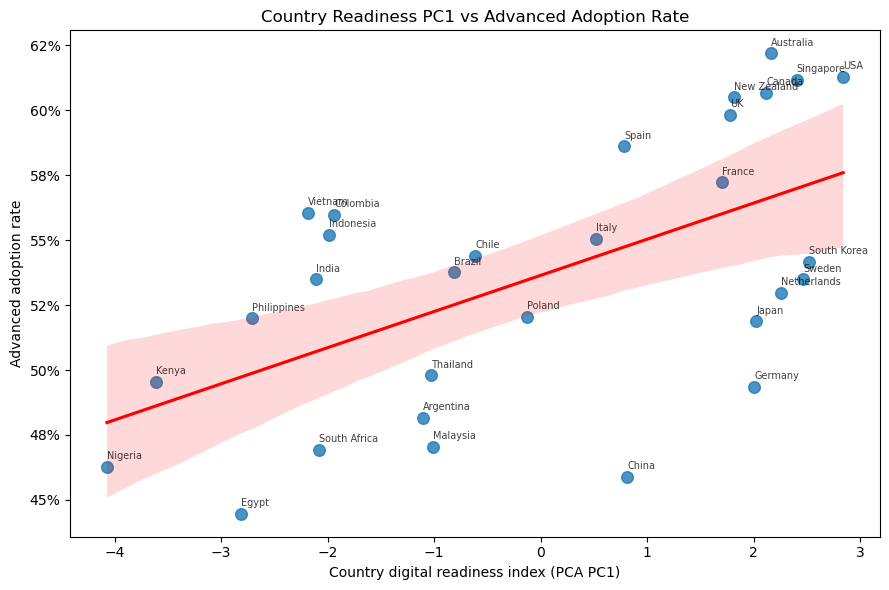

In [6]:
# PCA readiness index using standardised country readiness variables.
X_readiness = StandardScaler().fit_transform(country_level[readiness_features])
pca = PCA(n_components=2)
pca_scores = pca.fit_transform(X_readiness)

country_level['readiness_pc1'] = pca_scores[:, 0]
country_level['readiness_pc2'] = pca_scores[:, 1]

# Flip PC1 if needed so higher PC1 corresponds to higher digital maturity.
if country_level[['readiness_pc1', 'digital_maturity_index']].corr().iloc[0, 1] < 0:
    country_level['readiness_pc1'] *= -1
    pca.components_[0, :] *= -1

pca_loadings = pd.DataFrame({
    'feature': readiness_features,
    'PC1_loading': pca.components_[0],
    'PC2_loading': pca.components_[1]
})

print('PCA explained variance ratio')
print(pd.Series(pca.explained_variance_ratio_, index=['PC1', 'PC2']).round(3))
print('\nPCA loadings')
print(pca_loadings.round(3).to_string(index=False))

model_country_pc1 = ols('adv_adoption_rate ~ readiness_pc1', data=country_level).fit()
print('\nCountry-level OLS: advanced adoption rate ~ readiness PC1')
print(f'R2={model_country_pc1.rsquared:.3f}, Adj R2={model_country_pc1.rsquared_adj:.3f}, p={model_country_pc1.pvalues["readiness_pc1"]:.4f}')

fig, ax = plt.subplots(figsize=(9, 6))
sns.regplot(data=country_level, x='readiness_pc1', y='adv_adoption_rate', ax=ax,
            scatter_kws={'s': 70, 'alpha': 0.8}, line_kws={'color': 'red'})
for _, row in country_level.iterrows():
    ax.text(row['readiness_pc1'], row['adv_adoption_rate'] + 0.003, row['country'], fontsize=7, alpha=0.75)
ax.set_title('Country Readiness PC1 vs Advanced Adoption Rate')
ax.set_xlabel('Country digital readiness index (PCA PC1)')
ax.set_ylabel('Advanced adoption rate')
ax.yaxis.set_major_formatter(lambda x, pos: f'{x:.0%}')
plt.tight_layout()
plt.show()


Higher national digital readiness is linked to higher advanced AI adoption. All five readiness indicators are positively correlated with adoption, with correlations between about 0.43 and 0.64, and all are significant at p < 0.05.

Since these indicators are also strongly related to each other, we used PCA to combine them into one index. The first component explains about 87% of the variance. When we regress adoption on this PCA index, the adjusted R2 is 0.31, with p < 0.001.

This shows a clear positive relationship between digital readiness and advanced adoption. However, because we only have 30 countries, this result should be treated as exploratory rather than causal.
